## 1. ACF and PACF Analysis

Before fitting anything, I need to understand the autocorrelation structure of AAPL returns. ACF tells me the value of q, PACF tells me the value of p. If both plots show nothing significant, ARIMA has nothing to work with, which is what I expect will happen.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
import sys
import os
sys.path.append("..")

from src.ingest import TICKERS, ALL_TICKERS
from src.evaluate import evaluate, compare_models

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = "../data/processed/"
FIGURES_DIR = "../report/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

Task was destroyed but it is pending!
task: <Task pending name='Task-748' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\User\miniconda3\envs\invsto\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-749' coro=<Kernel.shell_main() running at C:\Users\User\miniconda3\envs\invsto\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\User\miniconda3\envs\invsto\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x0000026049AFB340>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-749' coro=<Kernel.shell_main() running at C:\Users\User\miniconda3\envs\invsto\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


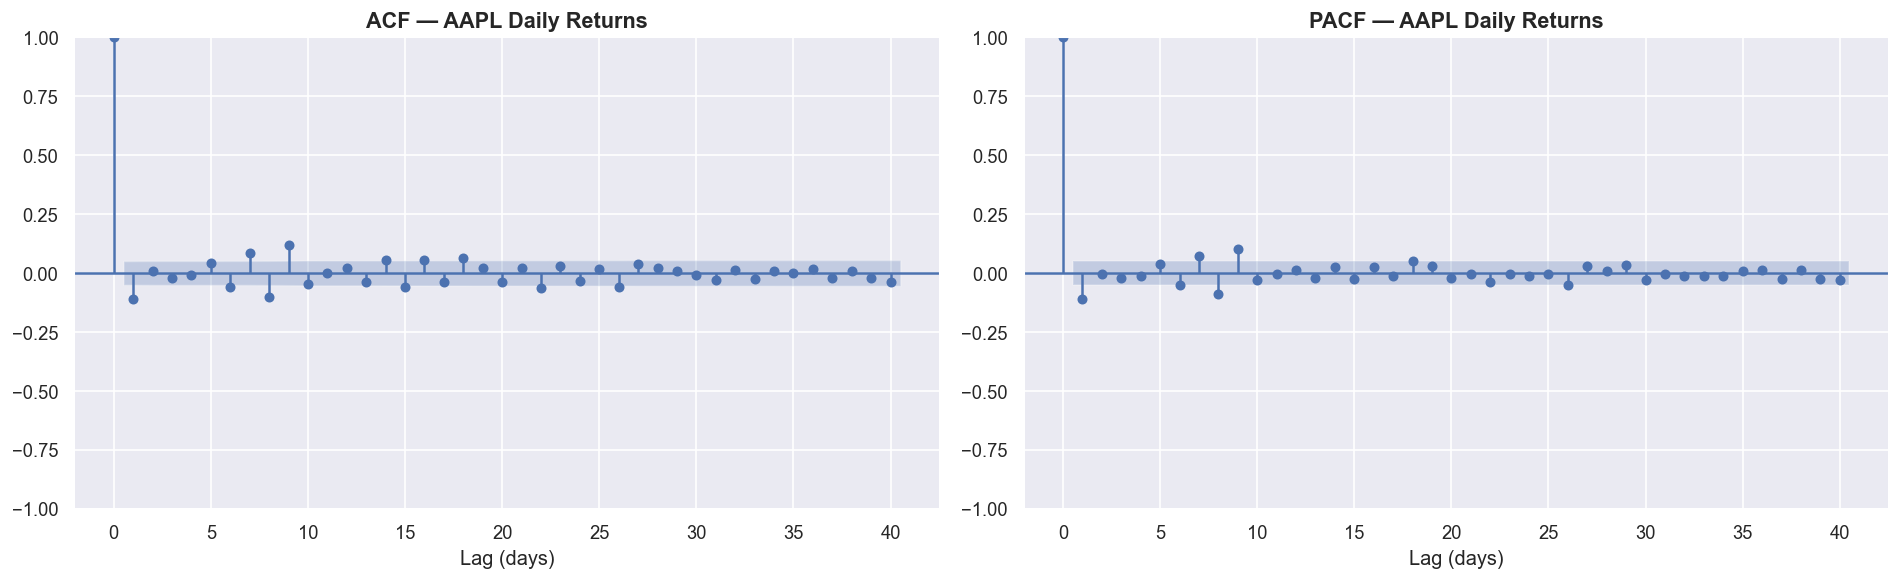

In [22]:
df = pd.read_csv(f"{PROCESSED_DIR}AAPL.csv", parse_dates=["Date"], index_col="Date")
returns = df["Close"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(returns, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — AAPL Daily Returns", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Lag (days)")

plot_pacf(returns, lags=40, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF — AAPL Daily Returns", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}08_acf_pacf.png", bbox_inches="tight")
plt.show()

Both ACF and PACF are almost entirely flat within the confidence bands. There is no meaningful correlation in AAPL daily returns at any lag. This is the random walk result. Past returns carry almost no information about future returns. ARIMA will have very little structure to model, which I will confirm in the grid search and forecast steps.

## 2. Grid search for optimal parameters

In [23]:
train_size = int(len(returns) * 0.8)
train, test = returns[:train_size], returns[train_size:]

print(f"Train: {len(train)} days ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {len(test)} days ({test.index[0].date()} to {test.index[-1].date()})")

results = []

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(train, order=(p, 0, q))
            fitted = model.fit()
            results.append({
                "p": p,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })
        except:
            continue

results_df = pd.DataFrame(results).sort_values("AIC")
print("\nTop 10 models by AIC:")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
best_p, best_q = int(best["p"]), int(best["q"])
print(f"\nBest model: ARIMA({best_p}, 0, {best_q}) — AIC: {best['AIC']:.2f}")

Train: 1206 days (2019-01-03 to 2023-10-17)
Test:  302 days (2023-10-18 to 2024-12-30)

Top 10 models by AIC:
 p  q          AIC          BIC
 1  0 -5954.015338 -5938.730144
 0  1 -5953.958752 -5938.673559
 1  1 -5952.004384 -5931.624127
 0  2 -5951.987853 -5931.607596
 2  0 -5951.986795 -5931.606538
 0  3 -5950.680843 -5925.205521
 3  0 -5950.395170 -5924.919848
 1  2 -5950.087036 -5924.611715
 2  1 -5950.086748 -5924.611426
 1  3 -5948.666128 -5918.095742

Best model: ARIMA(1, 0, 0) — AIC: -5954.02


## 3. Fitting ARIMA(1,0,0)

In [24]:
model = ARIMA(train, order=(best_p, 0, best_q))
fitted_model = model.fit()
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1206
Model:                 ARIMA(1, 0, 0)   Log Likelihood                2980.008
Date:                Tue, 26 May 2026   AIC                          -5954.015
Time:                        20:12:43   BIC                          -5938.730
Sample:                             0   HQIC                         -5948.259
                               - 1206                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      2.847      0.004       0.000       0.003
ar.L1         -0.1281      0.018     -6.941      0.000      -0.164      -0.092
sigma2         0.0004   1.01e-05     41.402      0.0

The AR(1) coefficient is -0.13 which is a slight mean reversion signal. It is statistically significant but economically very small. More importantly, the residual diagnostics show kurtosis = 7.36 and heteroskedasticity, neither of which ARIMA can model. It captured the little structure that existed but the hard parts cannot be modelled by ARIMA.

## 4. One step ahead forecast

Model                      RMSE        MAE       MAPE
ARIMA                  0.013851   0.010115    120.04%
Naive                  0.013713   0.010045    100.00%


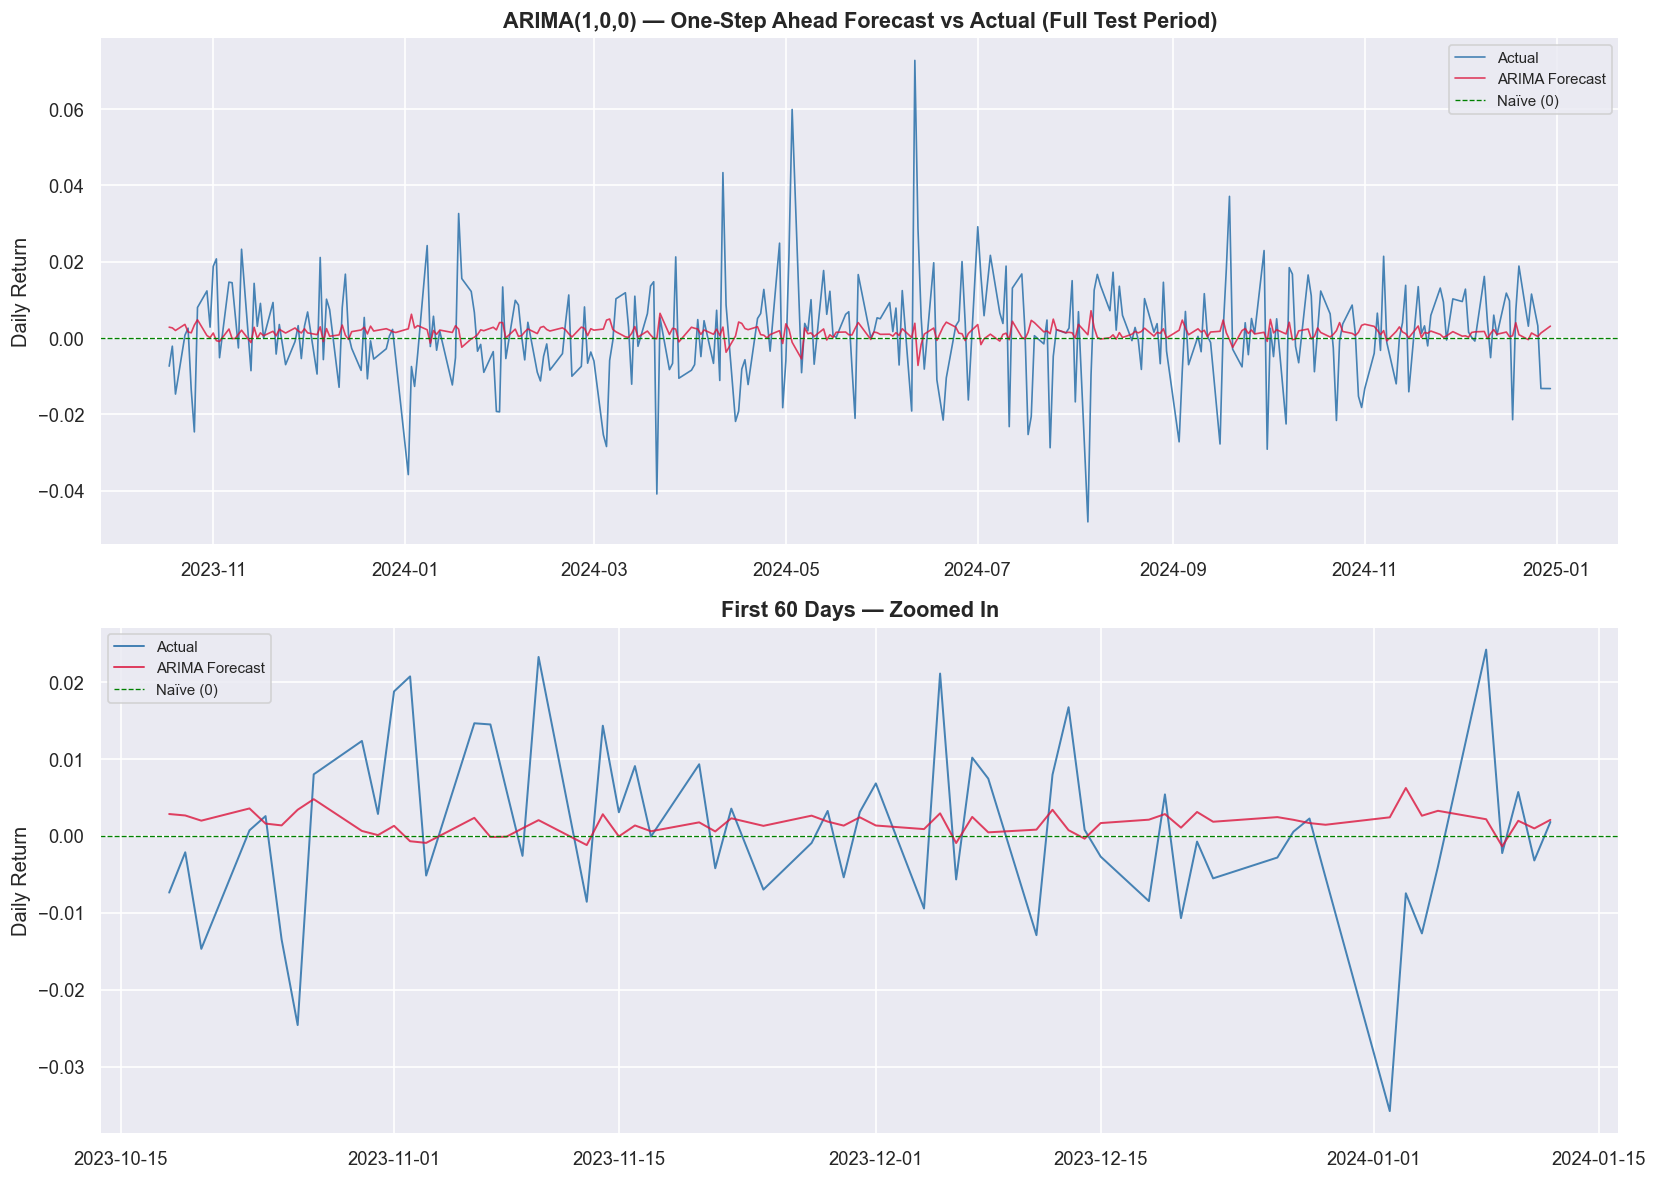

In [25]:
predictions = []

history = list(train)

for t in range(len(test)):
    model = ARIMA(history, order=(best_p, 0, best_q))
    fitted = model.fit()
    yhat = fitted.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

predictions = pd.Series(predictions, index=test.index)

naive_preds = np.zeros(len(test))

compare_models([
    evaluate(test, predictions, "ARIMA"),
    evaluate(test, naive_preds, "Naive"),
])

# plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# full test period
axes[0].plot(test.index, test.values, label="Actual", color="steelblue", linewidth=1)
axes[0].plot(predictions.index, predictions.values, label="ARIMA Forecast", 
             color="crimson", linewidth=1, alpha=0.8)
axes[0].axhline(0, color="green", linewidth=0.8, linestyle="--", label="Naïve (0)")
axes[0].set_title("ARIMA(1,0,0) — One-Step Ahead Forecast vs Actual (Full Test Period)", 
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Daily Return")
axes[0].legend(fontsize=9)

# zoom into first 60 days
axes[1].plot(test.index[:60], test.values[:60], label="Actual", color="steelblue", linewidth=1.2)
axes[1].plot(predictions.index[:60], predictions.values[:60], label="ARIMA Forecast",
             color="crimson", linewidth=1.2, alpha=0.8)
axes[1].axhline(0, color="green", linewidth=0.8, linestyle="--", label="Naïve (0)")
axes[1].set_title("First 60 Days — Zoomed In", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Daily Return")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}09_arima_onestep_forecast.png", bbox_inches="tight")
plt.show()

ARIMA is actually worse than just predicting zero every single day. The forecast line barely moves from zero because the model has almost nothing to work with. Past returns carry so little information about future returns that the model learns almost nothing. This is what the random walk looks like in practice.

## 5. Multi step forecast

Model                      RMSE        MAE       MAPE
ARIMA                  0.013851   0.010115    120.04%
Naive                  0.013713   0.010045    100.00%


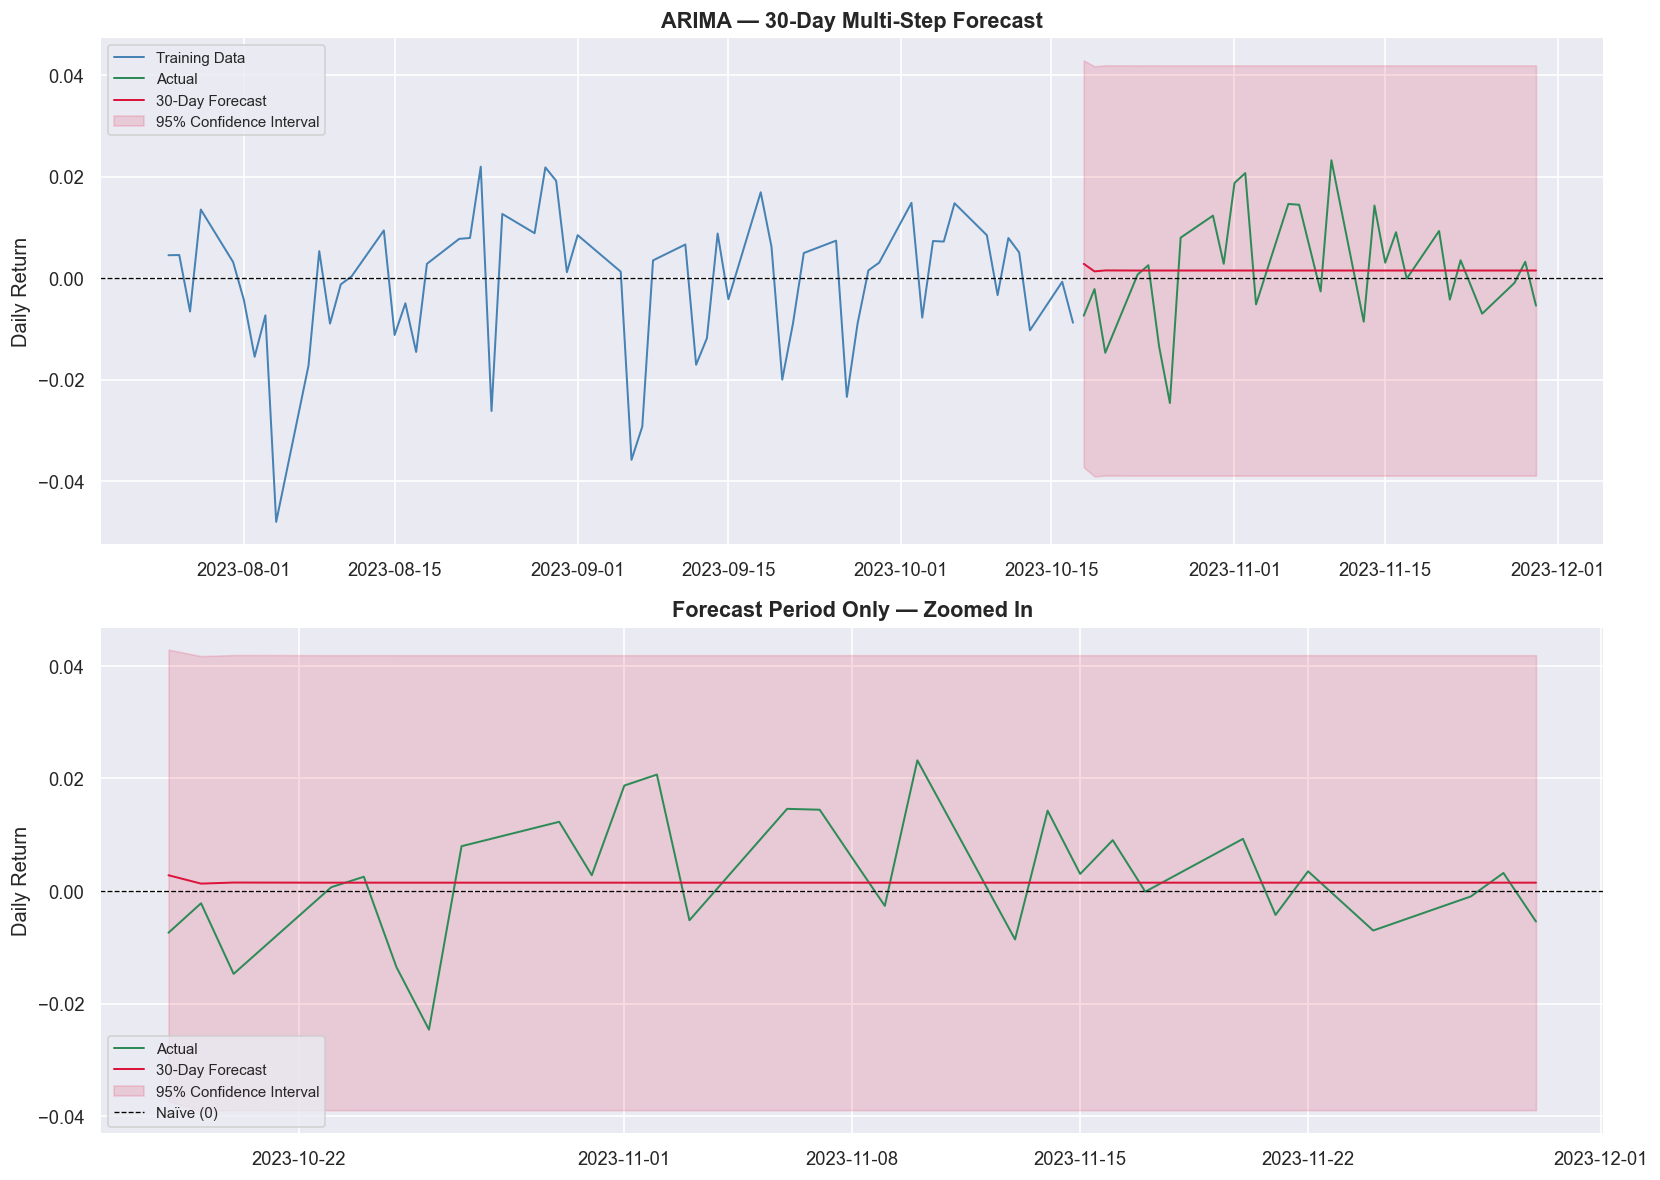

In [29]:
model = ARIMA(train, order=(best_p, 0, best_q))
fitted_model = model.fit()

forecast_steps = 30
forecast = fitted_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

forecast_index = test.index[:forecast_steps]
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

naive_preds = np.zeros(len(test))

compare_models([
    evaluate(test, predictions, "ARIMA"),
    evaluate(test, naive_preds, "Naive"),
])

# plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(train.index[-60:], train.values[-60:], label="Training Data",
        color="steelblue", linewidth=1.2)
axes[0].plot(test.index[:forecast_steps], test.values[:forecast_steps],
        label="Actual", color="seagreen", linewidth=1.2)
axes[0].plot(forecast_mean.index, forecast_mean.values,
        label="30-Day Forecast", color="crimson", linewidth=1.2)
axes[0].fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="crimson", alpha=0.15, label="95% Confidence Interval")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("ARIMA — 30-Day Multi-Step Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Daily Return")
axes[0].legend(fontsize=9)

# zoom into forecast only
axes[1].plot(test.index[:forecast_steps], test.values[:forecast_steps],
        label="Actual", color="seagreen", linewidth=1.2)
axes[1].plot(forecast_mean.index, forecast_mean.values,
        label="30-Day Forecast", color="crimson", linewidth=1.2)
axes[1].fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="crimson", alpha=0.15, label="95% Confidence Interval")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", label="Naïve (0)")
axes[1].set_title("Forecast Period Only — Zoomed In", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Daily Return")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}10_arima_multistep_forecast.png", bbox_inches="tight")
plt.show()

The 30 day forecast just predicts the same tiny number every single day. It looks better on RMSE because that number happens to be close to the average return, but that is not real forecasting. The pink confidence interval covers almost everything, meaning the model has no idea what will happen next.

## 6. Residual Diagnostics

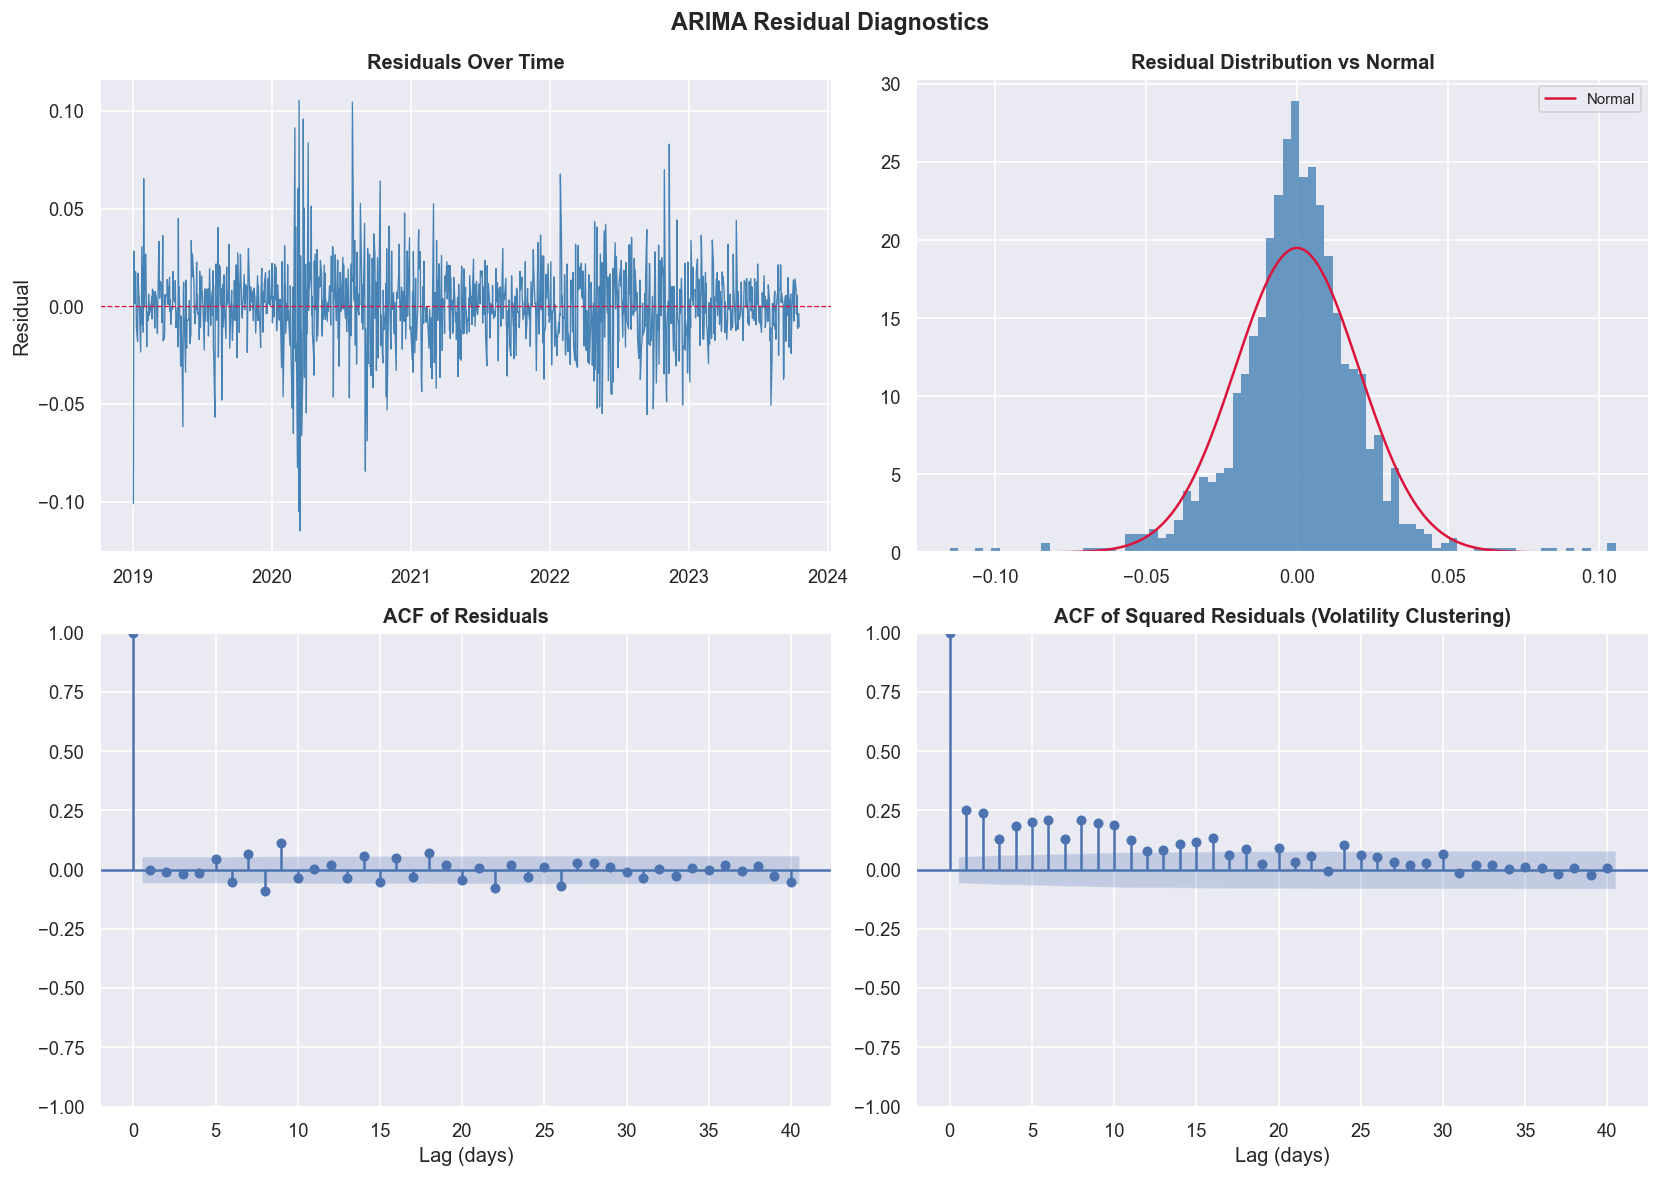

In [30]:
model = ARIMA(train, order=(best_p, 0, best_q))
fitted_model = model.fit()
residuals = fitted_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# residuals over time
axes[0, 0].plot(train.index, residuals, color="steelblue", linewidth=0.8)
axes[0, 0].axhline(0, color="crimson", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Residuals Over Time", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Residual")

# residual distribution
axes[0, 1].hist(residuals, bins=80, color="steelblue", edgecolor="none", 
                alpha=0.8, density=True)
mu, std = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 200)
normal_curve = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/std)**2)
axes[0, 1].plot(x, normal_curve, color="crimson", linewidth=1.5, label="Normal")
axes[0, 1].set_title("Residual Distribution vs Normal", fontsize=12, fontweight="bold")
axes[0, 1].legend(fontsize=9)

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF of Residuals", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Lag (days)")

# ACF of squared residuals (volatility clustering)
plot_acf(residuals**2, lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("ACF of Squared Residuals (Volatility Clustering)", 
                      fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Lag (days)")

plt.suptitle("ARIMA Residual Diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}11_arima_residuals.png", bbox_inches="tight")
plt.show()

The residuals look clean to me. There no leftover autocorrelation. But the squared residuals have big errors cluster together, especially around 2020. This is volatility clustering that ARIMA cannot model because it assumes constant variance. The fat tails in the residual distribution confirm what I have already shown from the return distributions.

## 7. Cross-Sector Validation

In [31]:
for ticker in ["JPM", "XOM"]:
    df_t = pd.read_csv(f"{PROCESSED_DIR}{ticker}.csv", parse_dates=["Date"], index_col="Date")
    ret = df_t["Close"].pct_change().dropna()
    
    train_t = ret[:int(len(ret) * 0.8)]
    test_t = ret[int(len(ret) * 0.8):]
    
    m = ARIMA(train_t, order=(1, 0, 0)).fit()
    preds = m.forecast(steps=len(test_t))
    preds.index = test_t.index
    
    naive_t = pd.Series(0, index=test_t.index)
    
    rmse_a = np.sqrt(mean_squared_error(test_t, preds))
    rmse_n = np.sqrt(mean_squared_error(test_t, naive_t))
    
    print(f"{ticker} — ARIMA RMSE: {rmse_a:.6f} | Naive RMSE: {rmse_n:.6f} | ARIMA {'BEATS' if rmse_a < rmse_n else 'LOSES TO'} naive")

JPM — ARIMA RMSE: 0.014109 | Naive RMSE: 0.014175 | ARIMA BEATS naive
XOM — ARIMA RMSE: 0.012068 | Naive RMSE: 0.012040 | ARIMA LOSES TO naive


JPM barely beats the naive forecast and XOM loses to it. The margins are so small they are  meaningless in practice. Across all three sectors, ARIMA either matches or loses to just predicting zero every day. This confirms the failure is structural, not specific to AAPL.

## Summary

ARIMA fails on stock returns for three reasons that showed up clearly in the diagnostics:

1. There is almost no autocorrelation in returns. The ACF and PACF were flat, giving ARIMA nothing to learn from

2. Volatility clusters showed strong correlation, meaning big moves follow big moves. ARIMA assumes constant variance and completely misses this

3. Residuals are not normally distributed, so ARIMA's confidence intervals are too narrow and it gets surprised by the moves that matter most

The naive forecast of zero beats or matches ARIMA across all three sectors tested. This is why I choose XGBoost to model this, since it is a model that makes no assumptions about linearity normality or constant variance, and can learn from a bigger set of features beyond just past returns.